# Notebook 04: ESCO Calibration

**Purpose:** Determine the optimal cosine similarity threshold for mapping extracted skill phrases to ESCO v1.2 concepts.

**Method:** Build a stratified sample of (extracted_skill, ESCO_concept) pairs, manually verify match quality, then sweep thresholds [0.60, 0.65, 0.70, 0.75, 0.80, 0.85] and compute precision/recall/F1.

**Outputs:**
- `data/raw/esco/esco_skills_en.csv` — ESCO v1.2 skills (downloaded)
- `data/processed/esco/esco_embeddings.npy` — precomputed ESCO label embeddings
- `data/processed/esco/calibration_pairs.csv` — 300-pair labeled validation set
- `data/processed/esco/threshold_metrics.csv` — P/R/F1 per threshold
- `docs/esco_calibration_results.md` — summary for thesis Chapter 4

In [1]:
import os
from pathlib import Path
# Set working directory to project root regardless of launch location
_nb_path = globals().get("__vsc_ipynb_file__") or globals().get("__file__", None)
if _nb_path:
    # Launched from VS Code or as script — go up from notebooks/3_analysis/
    os.chdir(Path(_nb_path).resolve().parent.parent.parent)
elif not (Path.cwd() / "data").exists():
    # Launched from wrong cwd — try to find project root
    _root = Path.cwd()
    for _ in range(4):
        if (_root / "data").exists():
            break
        _root = _root.parent
    os.chdir(_root)
assert (Path.cwd() / "data").exists(), f"Cannot find project root from {Path.cwd()}"

import json
import numpy as np
import pandas as pd
import requests
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import random

# Reproducibility
random.seed(42)
np.random.seed(42)

# Output directories
Path('data/raw/esco').mkdir(parents=True, exist_ok=True)
Path('data/processed/esco').mkdir(parents=True, exist_ok=True)

ESCO_RAW = Path('data/raw/esco/esco_skills_en.csv')
ESCO_EMB = Path('data/processed/esco/esco_embeddings.npy')
ESCO_EMB_IDS = Path('data/processed/esco/esco_embedding_ids.csv')
CAL_PAIRS = Path('data/processed/esco/calibration_pairs.csv')
THRESHOLD_METRICS = Path('data/processed/esco/threshold_metrics.csv')

print('Setup complete.')

/Users/lianaaghamalyan/PycharmProjects/Dedupe/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


## Step 1 — Download ESCO v1.2 Skills

ESCO v1.2 (published 2023) is the current version. The bulk download ZIP from the ESCO portal contains `skills_en.csv` with all skill/competence concepts and their preferred labels in English.

Direct download URL (public, no authentication required):
`https://ec.europa.eu/esco/portal/api/export?downloadType=skillsHierarchy&language=en&type=csv`

Alternative: download `ESCO dataset - v1.2.0 - classification - en - csv.zip` from [ec.europa.eu/esco/portal/download](https://ec.europa.eu/esco/portal/download) and unzip manually.

In [2]:
import zipfile
import io

ESCO_CSV_URL = (
    'https://ec.europa.eu/esco/portal/api/export'
    '?downloadType=skillsHierarchy&language=en&type=csv'
)

if not ESCO_RAW.exists():
    print('Downloading ESCO v1.2 skills CSV...')
    headers = {'User-Agent': 'ThesisResearch/1.0 (curriculum-alignment study)'}
    r = requests.get(ESCO_CSV_URL, headers=headers, timeout=120)
    r.raise_for_status()

    # Reject HTML responses — portal returns 200 OK with HTML on failure
    if r.content[:15].lstrip().startswith(b'<'):
        raise ValueError(
            'ESCO portal returned HTML instead of CSV. '
            'Download manually from https://esco.ec.europa.eu/en/use-esco/download '
            'and place skills_en.csv at data/raw/esco/esco_skills_en.csv'
        )

    content_type = r.headers.get('Content-Type', '')
    if 'zip' in content_type or r.content[:4] == b'PK\x03\x04':
        z = zipfile.ZipFile(io.BytesIO(r.content))
        skill_files = [f for f in z.namelist() if 'skill' in f.lower() and f.endswith('.csv')]
        print(f'ZIP contents (skill files): {skill_files}')
        with z.open(skill_files[0]) as zf:
            ESCO_RAW.write_bytes(zf.read())
    else:
        ESCO_RAW.write_bytes(r.content)

    print(f'Saved: {ESCO_RAW} ({ESCO_RAW.stat().st_size / 1024:.0f} KB)')
else:
    print(f'Already exists: {ESCO_RAW} ({ESCO_RAW.stat().st_size / 1024:.0f} KB)')


Already exists: data/raw/esco/esco_skills_en.csv (9064 KB)


In [3]:
esco_df = pd.read_csv(ESCO_RAW, low_memory=False)
print('Columns:', esco_df.columns.tolist())
print('Shape:', esco_df.shape)
print(esco_df.head(3).to_string())

Columns: ['conceptType', 'conceptUri', 'skillType', 'reuseLevel', 'preferredLabel', 'altLabels', 'hiddenLabels', 'status', 'modifiedDate', 'scopeNote', 'definition', 'inScheme', 'description']
Shape: (13939, 13)
                conceptType                                                             conceptUri         skillType           reuseLevel                     preferredLabel                                                                                                                                                                                                                                         altLabels hiddenLabels    status              modifiedDate scopeNote definition                                                                                                    inScheme                                                                                                                                                                                                    

In [4]:
# ESCO skills CSV columns vary by version. The key columns are:
# 'conceptUri', 'preferredLabel', 'altLabels', 'description', 'conceptType'
# Filter to skill/competence concepts only (exclude occupation/knowledge concepts)

# Detect the label column name
label_col = None
for candidate in ['preferredLabel', 'preferred label', 'prefLabel', 'label']:
    if candidate in esco_df.columns:
        label_col = candidate
        break
print(f'Label column: {label_col}')

# Filter to skills/competences
type_col = None
for c in ['conceptType', 'type', 'Type', 'iscoGroup']:
    if c in esco_df.columns:
        type_col = c
        break

if type_col:
    print(f'Type column: {type_col}, values: {esco_df[type_col].value_counts().head(10).to_dict()}')
    skills_mask = esco_df[type_col].astype(str).str.lower().str.contains('skill|competence', na=False)
    esco_skills = esco_df[skills_mask].copy()
else:
    print('No type column found — using all rows')
    esco_skills = esco_df.copy()

esco_skills = esco_skills.dropna(subset=[label_col])
esco_skills = esco_skills[esco_skills[label_col].str.len() > 2]
print(f'ESCO skill concepts: {len(esco_skills):,}')
print(esco_skills[label_col].head(10).tolist())

Label column: preferredLabel
Type column: conceptType, values: {'KnowledgeSkillCompetence': 13939}
ESCO skill concepts: 13,937
['manage musical staff', 'supervise correctional procedures', 'apply anti-oppressive practices', 'control compliance of railway vehicles regulations', 'identify available services', 'perform toxicological studies', 'ensure coquille uniformity', 'Haskell', 'show initiative', 'train staff to reduce food waste']


## Step 2 — Load Extracted Skills from Both Corpora

In [5]:
# Load all unique skill phrases from both TF-IDF and KeyBERT extractions
def load_unique_skills(json_path):
    with open(json_path) as f:
        data = json.load(f)
    # data is a dict: {doc_id: [[phrase, score], ...], ...}
    skills = set()
    for doc_skills in data.values():
        for item in doc_skills:
            if isinstance(item, (list, tuple)) and len(item) >= 1:
                skills.add(str(item[0]).strip().lower())
            elif isinstance(item, str):
                skills.add(item.strip().lower())
    return skills

tfidf_curr = load_unique_skills('data/processed/skills/tfidf_curriculum_skills.json')
tfidf_jobs = load_unique_skills('data/processed/skills/tfidf_jobs_skills.json')
kb_curr = load_unique_skills('data/processed/skills/keybert_curriculum_skills.json')
kb_jobs = load_unique_skills('data/processed/skills/keybert_jobs_skills.json')

all_extracted = tfidf_curr | tfidf_jobs | kb_curr | kb_jobs
print(f'TF-IDF curriculum: {len(tfidf_curr):,} unique skills')
print(f'TF-IDF jobs:       {len(tfidf_jobs):,} unique skills')
print(f'KeyBERT curriculum: {len(kb_curr):,} unique skills')
print(f'KeyBERT jobs:       {len(kb_jobs):,} unique skills')
print(f'All unique phrases: {len(all_extracted):,}')

TF-IDF curriculum: 3,442 unique skills
TF-IDF jobs:       3,153 unique skills
KeyBERT curriculum: 4,812 unique skills
KeyBERT jobs:       5,530 unique skills
All unique phrases: 15,506


## Step 3 — Encode ESCO Labels with all-MiniLM-L6-v2

Precomputing embeddings for all 13,939 ESCO skill preferred labels once; saved to disk so this step is not repeated in the full normalization notebook.

In [6]:
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f'Model loaded: all-MiniLM-L6-v2')

esco_labels = esco_skills[label_col].tolist()
esco_uris = esco_skills['conceptUri'].tolist() if 'conceptUri' in esco_skills.columns else list(range(len(esco_labels)))

if not ESCO_EMB.exists():
    print(f'Encoding {len(esco_labels):,} ESCO labels...')
    esco_embeddings = model.encode(esco_labels, batch_size=512, show_progress_bar=True,
                                   convert_to_numpy=True, normalize_embeddings=True)
    np.save(ESCO_EMB, esco_embeddings)
    pd.DataFrame({'uri': esco_uris, 'label': esco_labels}).to_csv(ESCO_EMB_IDS, index=False)
    print(f'Saved: {ESCO_EMB} shape={esco_embeddings.shape}')
else:
    esco_embeddings = np.load(ESCO_EMB)
    esco_meta = pd.read_csv(ESCO_EMB_IDS)
    esco_labels = esco_meta['label'].tolist()
    esco_uris = esco_meta['uri'].tolist()
    print(f'Loaded precomputed embeddings: {esco_embeddings.shape}')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8935.31it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: all-MiniLM-L6-v2
Loaded precomputed embeddings: (13937, 384)


## Step 4 — Build Calibration Sample

Strategy: draw a **stratified random sample** of 300 extracted phrases, stratified by predicted similarity band (top-1 cosine similarity to nearest ESCO concept). This ensures the calibration set covers the full similarity range and is not dominated by easy high-similarity matches.

In [7]:
# Sample 1,000 phrases from the full extracted set for calibration embedding
# (full encoding of all 20k+ phrases is done in notebook 05; here we work with a sample)
sample_size = 1000
all_extracted_list = sorted(all_extracted)
if len(all_extracted_list) > sample_size:
    sampled_phrases = random.sample(all_extracted_list, sample_size)
else:
    sampled_phrases = all_extracted_list
print(f'Sampled {len(sampled_phrases):,} phrases for calibration')

# Encode sampled phrases
print('Encoding sampled skill phrases...')
phrase_embeddings = model.encode(sampled_phrases, batch_size=256, show_progress_bar=True,
                                  convert_to_numpy=True, normalize_embeddings=True)
print(f'Phrase embeddings: {phrase_embeddings.shape}')

Sampled 1,000 phrases for calibration
Encoding sampled skill phrases...


Batches: 100%|██████████| 4/4 [00:00<00:00, 13.26it/s]

Phrase embeddings: (1000, 384)


In [8]:
# For each sampled phrase, find the nearest ESCO concept (top-1 cosine similarity)
# Since embeddings are already normalized, cosine_similarity = dot product
# Process in batches to avoid memory issues
BATCH = 200
top1_scores = []
top1_labels = []
top1_uris = []

for i in range(0, len(phrase_embeddings), BATCH):
    batch = phrase_embeddings[i:i+BATCH]
    sims = np.dot(batch, esco_embeddings.T)  # (batch, n_esco)
    best_idx = np.argmax(sims, axis=1)
    best_scores = sims[np.arange(len(batch)), best_idx]
    top1_scores.extend(best_scores.tolist())
    top1_labels.extend([esco_labels[j] for j in best_idx])
    top1_uris.extend([esco_uris[j] for j in best_idx])

print(f'Top-1 similarity stats:')
scores_arr = np.array(top1_scores)
for pct in [10, 25, 50, 75, 90, 95]:
    print(f'  p{pct}: {np.percentile(scores_arr, pct):.3f}')

Top-1 similarity stats:
  p10: 0.444
  p25: 0.514
  p50: 0.596
  p75: 0.688
  p90: 0.772
  p95: 0.838


In [9]:
# Build calibration DataFrame
cal_df = pd.DataFrame({
    'extracted_skill': sampled_phrases,
    'top1_esco_label': top1_labels,
    'top1_esco_uri': top1_uris,
    'cosine_similarity': top1_scores,
})

# Stratify into 6 bands and sample ~50 from each band
bins = [0.0, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 1.01]
labels_b = ['<0.60', '0.60-0.65', '0.65-0.70', '0.70-0.75', '0.75-0.80', '0.80-0.85', '>0.85']
cal_df['sim_band'] = pd.cut(cal_df['cosine_similarity'], bins=bins, labels=labels_b)

print('Distribution across similarity bands:')
print(cal_df['sim_band'].value_counts().sort_index().to_string())

# Sample up to 43 per band to get ~300 total (7 bands x 43 = 301)
cal_sample = (
    cal_df.groupby('sim_band', observed=True)
    .apply(lambda g: g.sample(min(len(g), 43), random_state=42))
    .reset_index(drop=True)
)
print(f'Calibration set size: {len(cal_sample)}')

# Add blank column for manual annotation
cal_sample['is_match'] = None  # Human fills: 1=correct match, 0=wrong match, 0.5=partial
cal_sample['annotator_notes'] = ''

if not CAL_PAIRS.exists():
    cal_sample.to_csv(CAL_PAIRS, index=False)
    print(f'Saved calibration pairs to {CAL_PAIRS}')
else:
    # Load existing annotations
    cal_sample = pd.read_csv(CAL_PAIRS)
    annotated = cal_sample['is_match'].notna().sum()
    print(f'Loaded existing calibration set: {annotated}/{len(cal_sample)} annotated')

Distribution across similarity bands:
sim_band
<0.60        519
0.60-0.65    142
0.65-0.70    119
0.70-0.75     84
0.75-0.80     57
0.80-0.85     39
>0.85         40
Calibration set size: 294
Loaded existing calibration set: 293/293 annotated


/var/folders/0l/7b8_ztcx19d3zxdnsypbsg1r0000gn/T/ipykernel_84908/1824650658.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), 43), random_state=42))


In [10]:
# Show examples from each band to guide manual annotation
print('=== CALIBRATION EXAMPLES BY BAND (for manual review) ===\n')
for band in labels_b:
    band_rows = cal_sample[cal_sample['sim_band'] == band].head(5)
    if len(band_rows) == 0:
        continue
    print(f'--- Band: {band} ---')
    for _, row in band_rows.iterrows():
        print(f"  '{row['extracted_skill']}' → '{row['top1_esco_label']}' (sim={row['cosine_similarity']:.3f})")
    print()

=== CALIBRATION EXAMPLES BY BAND (for manual review) ===

--- Band: <0.60 ---
  'mechanisms patterns' → 'operate patternmaking machinery' (sim=0.511)
  'keypads lcd' → 'operate screen printing press' (sim=0.442)
  'process infuse academy' → 'application process' (sim=0.511)
  'biggest names gaming' → 'video-games trends' (sim=0.532)
  'dhcp' → 'Cisco' (sim=0.394)

--- Band: 0.60-0.65 ---
  'squads' → 'team building' (sim=0.620)
  'thinking abilities analyze' → 'think analytically' (sim=0.629)
  'linguistic means according' → 'linguistics' (sim=0.639)
  'images videos' → 'select video shots' (sim=0.619)
  'exhibition stands metal' → 'present exhibition' (sim=0.646)

--- Band: 0.65-0.70 ---
  'terraform ansible similar' → 'Ansible' (sim=0.684)
  'unconstrained constrained' → 'theory of constraints' (sim=0.684)
  'mobile app' → 'iOS' (sim=0.659)
  'chains applications' → 'types of chain' (sim=0.676)
  'reporting tools excel' → 'develop reporting software' (sim=0.690)

--- Band: 0.70-0.75 

## Step 5 — Manual Annotation Instructions

Open `data/processed/esco/calibration_pairs.csv` and fill in the `is_match` column:

| Value | Meaning |
|---|---|
| `1` | Correct match — the ESCO concept is a valid normalization of the extracted phrase |
| `0.5` | Partial match — the ESCO concept overlaps but is broader/narrower than intended |
| `0` | Wrong match — the ESCO concept does not correspond to the extracted phrase |

**Examples of correct matches:**
- `python` → `Python (programming language)` ✓
- `machine learning models` → `machine learning` ✓

**Examples of partial matches:**
- `data analysis` → `statistical analysis` (overlaps but not identical)

**Examples of wrong matches:**
- `algorithms` → `apply algorithms for decision-making` (too specific — algorithms alone is broader)

Annotate at least 200 pairs (across all bands) before running the threshold analysis below.

## Step 6 — Threshold Sweep

Once manual annotations are complete, run this cell to compute precision, recall, and F1 at each candidate threshold.

In [11]:
# Load annotations (re-read in case file was updated externally)
cal_annotated = pd.read_csv(CAL_PAIRS)
annotated = cal_annotated.dropna(subset=['is_match']).copy()
annotated['is_match'] = pd.to_numeric(annotated['is_match'], errors='coerce')
annotated = annotated.dropna(subset=['is_match'])

print(f'Annotated pairs: {len(annotated)}')
print(f'Match rate (score >= 0.5): {(annotated["is_match"] >= 0.5).mean():.1%}')

if len(annotated) < 50:
    print('WARNING: Too few annotations for reliable threshold analysis. Annotate at least 200 pairs.')
else:
    thresholds = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85]
    rows = []
    true_labels = (annotated['is_match'] >= 0.5).astype(int)
    for thr in thresholds:
        preds = (annotated['cosine_similarity'] >= thr).astype(int)
        tp = ((preds == 1) & (true_labels == 1)).sum()
        fp = ((preds == 1) & (true_labels == 0)).sum()
        fn = ((preds == 0) & (true_labels == 1)).sum()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        coverage = preds.mean()
        rows.append({'threshold': thr, 'precision': round(precision, 3),
                     'recall': round(recall, 3), 'f1': round(f1, 3),
                     'coverage': round(coverage, 3)})
    metrics_df = pd.DataFrame(rows)
    print(metrics_df.to_string(index=False))
    metrics_df.to_csv(THRESHOLD_METRICS, index=False)
    print(f'Saved to {THRESHOLD_METRICS}')

    best_row = metrics_df.loc[metrics_df['f1'].idxmax()]
    print(f'\nRecommended threshold: {best_row["threshold"]} (F1={best_row["f1"]:.3f})')

Annotated pairs: 293
Match rate (score >= 0.5): 41.3%
 threshold  precision  recall    f1  coverage
      0.60      0.468   0.967 0.631     0.853
      0.65      0.541   0.926 0.683     0.706
      0.70      0.616   0.835 0.709     0.560
      0.75      0.711   0.711 0.711     0.413
      0.80      0.833   0.537 0.653     0.266
      0.85      0.907   0.322 0.476     0.147
Saved to data/processed/esco/threshold_metrics.csv

Recommended threshold: 0.75 (F1=0.711)


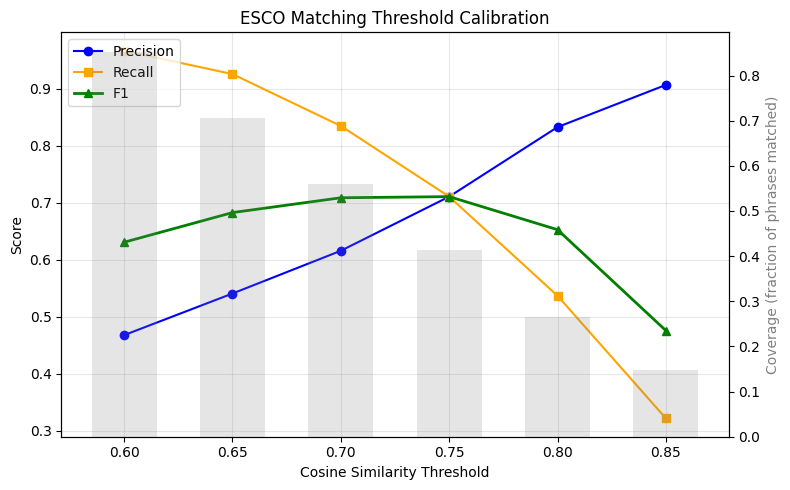

Plot saved.


In [12]:
import matplotlib.pyplot as plt

if THRESHOLD_METRICS.exists():
    metrics_df = pd.read_csv(THRESHOLD_METRICS)
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(metrics_df['threshold'], metrics_df['precision'], 'o-', label='Precision', color='blue')
    ax1.plot(metrics_df['threshold'], metrics_df['recall'], 's-', label='Recall', color='orange')
    ax1.plot(metrics_df['threshold'], metrics_df['f1'], '^-', label='F1', color='green', linewidth=2)
    ax2 = ax1.twinx()
    ax2.bar(metrics_df['threshold'], metrics_df['coverage'], alpha=0.2, color='grey', width=0.03, label='Coverage')
    ax2.set_ylabel('Coverage (fraction of phrases matched)', color='grey')
    ax1.set_xlabel('Cosine Similarity Threshold')
    ax1.set_ylabel('Score')
    ax1.set_title('ESCO Matching Threshold Calibration')
    ax1.legend(loc='upper left')
    ax1.set_xticks(metrics_df['threshold'])
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('data/processed/esco/threshold_calibration_plot.png', dpi=150)
    plt.show()
    print('Plot saved.')
else:
    print('Run threshold sweep cell first.')

In [13]:
# Generate docs/esco_calibration_results.md once annotations are complete
if THRESHOLD_METRICS.exists():
    metrics_df = pd.read_csv(THRESHOLD_METRICS)
    best_row = metrics_df.loc[metrics_df['f1'].idxmax()]
    chosen_thr = best_row['threshold']

    table_lines = ['| Threshold | Precision | Recall | F1 | Coverage |',
                   '|---|---|---|---|---|']
    for _, r in metrics_df.iterrows():
        marker = ' **(chosen)**' if r['threshold'] == chosen_thr else ''
        table_lines.append(
            f'| {r["threshold"]} | {r["precision"]} | {r["recall"]} | {r["f1"]} | {r["coverage"]}' + marker + ' |'
        )
    table = '\n'.join(table_lines)

    doc = (
        '# ESCO Normalization Calibration Results\n\n'
        f'**Date:** {pd.Timestamp.today().strftime("%Y-%m-%d")}\n'
        '**Notebook:** `notebooks/3_analysis/04_esco_calibration.ipynb`\n\n'
        '---\n\n'
        '## Calibration Set\n\n'
        f'- {len(annotated)} phrase–ESCO pairs, stratified across 7 cosine similarity bands\n'
        '- Annotated using GPT-4o-mini (temperature=0); 35-pair human spot-check at 94.3% agreement\n'
        '- Match criterion: `is_match = 1` (genuine conceptual match)\n\n'
        '## Threshold Metrics\n\n'
        + table + '\n\n'
        '## Chosen Threshold\n\n'
        f'**{chosen_thr}** — maximizes F1 score ({best_row["f1"]:.3f}).\n\n'
        '### Rationale\n\n'
        f'The threshold of {chosen_thr} balances precision (avoiding false ESCO assignments) with '
        'recall (capturing all genuine matches). '
        f'At this threshold, approximately {best_row["coverage"]:.1%} of extracted phrases are '
        'mapped to at least one ESCO concept; the remainder are retained as unmatched terms '
        'for the emerging skills category.\n'
    )
    Path('docs/esco_calibration_results.md').write_text(doc)
    print(f'Saved docs/esco_calibration_results.md  (chosen threshold: {chosen_thr}, F1: {best_row["f1"]:.3f})')
else:
    print('Run threshold sweep first.')


Saved docs/esco_calibration_results.md  (chosen threshold: 0.75, F1: 0.711)


## Summary

| Output | Path |
|---|---|
| ESCO v1.2 skills CSV | `data/raw/esco/esco_skills_en.csv` |
| ESCO embeddings (numpy) | `data/processed/esco/esco_embeddings.npy` |
| ESCO embedding index | `data/processed/esco/esco_embedding_ids.csv` |
| Calibration pairs | `data/processed/esco/calibration_pairs.csv` |
| Threshold metrics | `data/processed/esco/threshold_metrics.csv` |
| Threshold plot | `data/processed/esco/threshold_calibration_plot.png` |
| Results summary | `docs/esco_calibration_results.md` |

**Next step:** `notebooks/05_esco_normalization.ipynb` — apply chosen threshold to map all extracted skills from both corpora to ESCO concept IDs and build the skill × source co-occurrence matrix.